In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import keras.layers as lay
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

2025-08-31 00:57:45.318141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756601865.349387 2930170 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756601865.358547 2930170 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756601865.382074 2930170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756601865.382101 2930170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756601865.382104 2930170 computation_placer.cc:177] computation placer alr

In [2]:
batch_size = 2**10

In [3]:
(trainx,trainy),(valx,valy) = keras.datasets.cifar10.load_data()
trainx = (tf.cast(trainx,tf.float32)-127.5)/127.5
valx = (tf.cast(valx,tf.float32)-127.5)/127.5

train = tf.data.Dataset.from_tensor_slices((trainx,trainy))
train = train.cache()
train = train.shuffle(2**10)
train = train.batch(batch_size)
train = train.prefetch(tf.data.AUTOTUNE)

val = tf.data.Dataset.from_tensor_slices((valx,valy))
val = val.cache()
val = val.shuffle(2**10)
val = val.batch(batch_size)
val = val.prefetch(tf.data.AUTOTUNE)

I0000 00:00:1756601873.197380 2930170 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


In [4]:
inputs = lay.Input((32,32,3))
x = inputs
skip = lay.Conv2D(128,(1,1),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(128,(3,3),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(128,(3,3),(1,1),'same',activation='leaky_relu')(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(256,(1,1),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(256,(3,3),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(256,(3,3),(1,1),'same',activation='leaky_relu')(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(256,(1,1),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(256,(3,3),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(256,(3,3),(1,1),'same',activation='leaky_relu')(x) + skip
x = lay.MaxPool2D()(x)
skip = lay.Conv2D(512,(1,1),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(512,(3,3),(1,1),'same',activation='leaky_relu')(x)
x = lay.Conv2D(512,(3,3),(1,1),'same',activation='leaky_relu')(x) + skip
x = lay.MaxPool2D()(x)

x = lay.Flatten()(x)
x = lay.Dense(128,'leaky_relu')(x)
x = lay.Dense(10,'softmax')(x)

model = keras.Model(inputs,x)
keras.models.save_model(model,'model.keras')

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      3,584 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        512 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 128)              │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     33,024 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ conv2d_5[0][0],   │
│                     │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 256) │          0 │ add_1[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │     65,792 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 8, 256) │          0 │ conv2d_8[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 4, 4, 256) │          0 │ add_2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 4, 4, 512) │  1,180,160 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 4, 4, 512) │  2,359,808 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,251,018 (23.85 MB)

 Trainable params: 6,251,018 (23.85 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=["Accuracy"])

In [7]:
history = model.fit(
    train,
    epochs=50,
    validation_data=val,
    callbacks=[keras.callbacks.EarlyStopping('val_loss',patience=10)]
)

Epoch 1/50


I0000 00:00:1756601880.115765 2930216 service.cc:152] XLA service 0x7cd6dc002bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756601880.115821 2930216 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-31 00:58:00.239228: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756601880.820241 2930216 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-31 00:58:03.699168: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 536 bytes spill stores, 536 bytes spill loads

2025-08-31 00:58:04.134616: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_119

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - Accuracy: 0.2514 - loss: 2.0541

2025-08-31 00:58:58.797024: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191_0', 68 bytes spill stores, 68 bytes spill loads

2025-08-31 00:58:59.185564: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 124 bytes spill stores, 124 bytes spill loads

2025-08-31 00:58:59.496406: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 160 bytes spill stores, 160 bytes spill loads

2025-08-31 00:58:59.955089: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1191', 160 bytes spill stores, 160 bytes spill loads

2025-08-31 00:59:00.106665: I ex

49/49 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - Accuracy: 0.3292 - loss: 1.8633 - val_Accuracy: 0.4330 - val_loss: 1.5812
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 352ms/step - Accuracy: 0.4731 - loss: 1.4683 - val_Accuracy: 0.5163 - val_loss: 1.3600
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 352ms/step - Accuracy: 0.5324 - loss: 1.3144 - val_Accuracy: 0.5377 - val_loss: 1.2830
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step - Accuracy: 0.5753 - loss: 1.2063 - val_Accuracy: 0.5748 - val_loss: 1.1933
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 352ms/step - Accuracy: 0.6081 - loss: 1.1204 - val_Accuracy: 0.5995 - val_loss: 1.1139
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step - Accuracy: 0.6297 - loss: 1.0552 - val_Accuracy: 0.6201 - val_loss: 1.0740
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step - Accuracy: 0.6589 - loss: 0.9821 - val_Accuracy: 0.6379 - val_loss: 1.0220
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 353ms/step - Accuracy: 0.6821 - loss: 0.9188 - val_Accuracy: 0.6498 

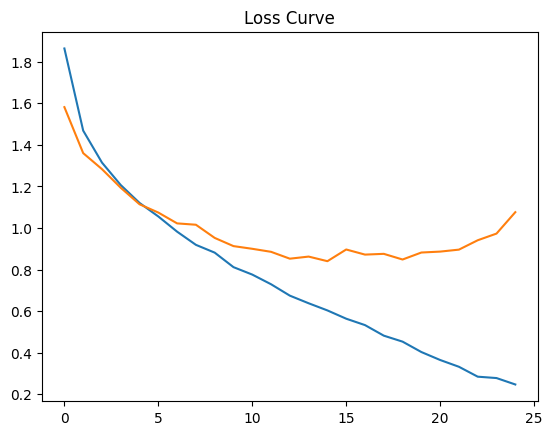

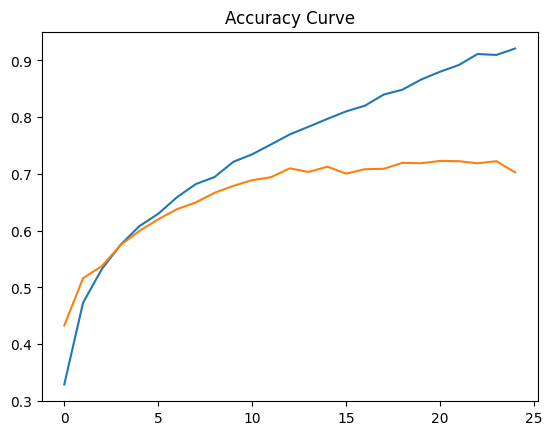

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.show()

plt.plot(history.history['Accuracy'])
plt.plot(history.history['val_Accuracy'])
plt.title('Accuracy Curve')
plt.show()

(10000, 32, 32, 3)
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


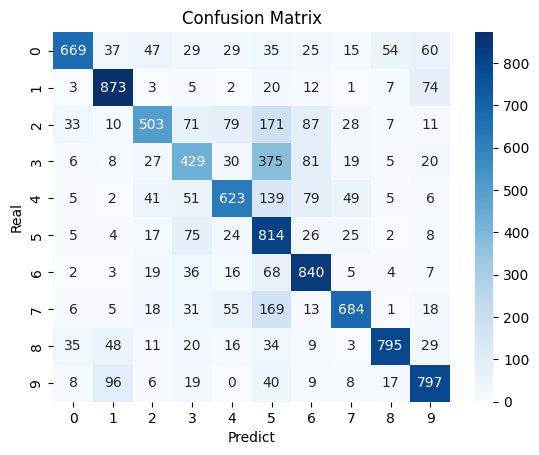

In [ ]:
print(valx.shape)
predicts = model.predict(valx)
predicts = np.argmax(predicts,axis=-1)
matrix = confusion_matrix(valy,predicts)

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predict')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()